# Network-wise Dice similarity between group parcellations

This notebook visualizes the network correspondence tables used for the task/rest group parcellation comparisons. Group parcellations are trained by the root [`train_group.py`](../../train_group.py) workflow; this notebook uses the precomputed network-wise Dice tables in `results/3.task_rest`.

Table mapping:
- Table S3: Figure panel 2c, `HBP17REST` vs `MSHBM17`
- Table S6: Supplementary figure panel 3c, `HBP17REST` vs `YEO17`
- Table S7: Main figure panel 3c, `HBP17REST` vs `HBP17TASK`
- Table S8: Main figure panel 4b, `HBP17FUSION` vs `HBP17REST`
- Table S9: Main figure panel 4c, `HBP17FUSION` vs `HBP17TASK`

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", context="talk")

In [2]:
def find_repo_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "train_group.py").exists() and (path / "results").exists():
            return path
    raise FileNotFoundError("Could not locate the IndividualParcellation repo root.")


REPO_ROOT = find_repo_root()
TABLE_DIR = REPO_ROOT / "results" / "3.task_rest"
OUTPUT_DIR = TABLE_DIR / "figures"
SAVE_FIGURES = False

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_GROUP_SCRIPT = REPO_ROOT / "train_group.py"
TABLE_DIR

PosixPath('/home/dzhi/Workspace/IndividualParcellation/results/3.task_rest')

In [3]:
TABLE_INFO = [
    {
        "table": "Table S3",
        "panel": "Figure 2c",
        "comparison": "HBP17REST vs MSHBM17",
        "file": "Table_S3_network_correspondence_HBP17REST_vs_MSHBM17.csv",
    },
    {
        "table": "Table S6",
        "panel": "Supplementary Figure 3c",
        "comparison": "HBP17REST vs YEO17",
        "file": "Table_S6_network_correspondence_HBP17REST_vs_YEO17.csv",
    },
    {
        "table": "Table S7",
        "panel": "Figure 3c",
        "comparison": "HBP17REST vs HBP17TASK",
        "file": "Table_S7_network_correspondence_HBP17REST_vs_HBP17TASK.csv",
    },
    {
        "table": "Table S8",
        "panel": "Figure 4b",
        "comparison": "HBP17FUSION vs HBP17REST",
        "file": "Table_S8_network_correspondence_HBP17FUSION_vs_HBP17REST.csv",
    },
    {
        "table": "Table S9",
        "panel": "Figure 4c",
        "comparison": "HBP17FUSION vs HBP17TASK",
        "file": "Table_S9_network_correspondence_HBP17FUSION_vs_HBP17TASK.csv",
    },
]

The table cells are stored as strings like `0.5794\n(p=0.0010)`. The parser below extracts the leading Dice coefficient and drops empty padding rows/columns, including the extra unnamed fields in Table S7.

In [4]:
def clean_label(label):
    if pd.isna(label):
        return None
    label = str(label).strip()
    if not label or label.startswith("Unnamed:"):
        return None
    return label


def extract_dice(cell):
    if pd.isna(cell):
        return np.nan
    text = str(cell).strip()
    if not text:
        return np.nan
    match = re.search(r"[-+]?\d*\.\d+|[-+]?\d+", text)
    return float(match.group(0)) if match else np.nan


def load_dice_matrix(csv_path):
    raw = pd.read_csv(csv_path, dtype=str)
    row_name_col = raw.columns[0]
    raw = raw.rename(columns={row_name_col: "network"})
    raw["network"] = raw["network"].map(clean_label)
    raw = raw.loc[raw["network"].notna()].copy()

    valid_cols = [col for col in raw.columns[1:] if clean_label(col) is not None]
    raw = raw[["network", *valid_cols]].set_index("network")
    raw.columns = [clean_label(col) for col in raw.columns]

    matrix = raw.apply(lambda col: col.map(extract_dice))
    matrix = matrix.dropna(axis=0, how="all").dropna(axis=1, how="all")
    return matrix

In [5]:
dice_matrices = {}
summary_rows = []

for item in TABLE_INFO:
    matrix = load_dice_matrix(TABLE_DIR / item["file"])
    dice_matrices[item["table"]] = matrix
    summary_rows.append({
        "table": item["table"],
        "panel": item["panel"],
        "comparison": item["comparison"],
        "shape": f"{matrix.shape[0]} x {matrix.shape[1]}",
        "max_dice": float(np.nanmax(matrix.values)),
    })

pd.DataFrame(summary_rows)

,table,panel,comparison,shape,max_dice
0,Table S3,Figure 2c,HBP17REST vs MSHBM17,17 x 17,0.9246
1,Table S6,Supplementary Figure 3c,HBP17REST vs YEO17,17 x 17,0.8875
2,Table S7,Figure 3c,HBP17REST vs HBP17TASK,17 x 17,0.7141
3,Table S8,Figure 4b,HBP17FUSION vs HBP17REST,17 x 17,0.8973
4,Table S9,Figure 4c,HBP17FUSION vs HBP17TASK,17 x 17,0.9097


In [6]:
def plot_dice_matrix(matrix, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        matrix,
        ax=ax,
        cmap="viridis",
        vmin=0,
        vmax=1,
        linewidths=0.35,
        linecolor="white",
        cbar_kws={"label": "Dice coefficient"},
    )
    ax.set_title(title, pad=16)
    ax.set_xlabel("Network in second parcellation")
    ax.set_ylabel("Network in first parcellation")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    return ax

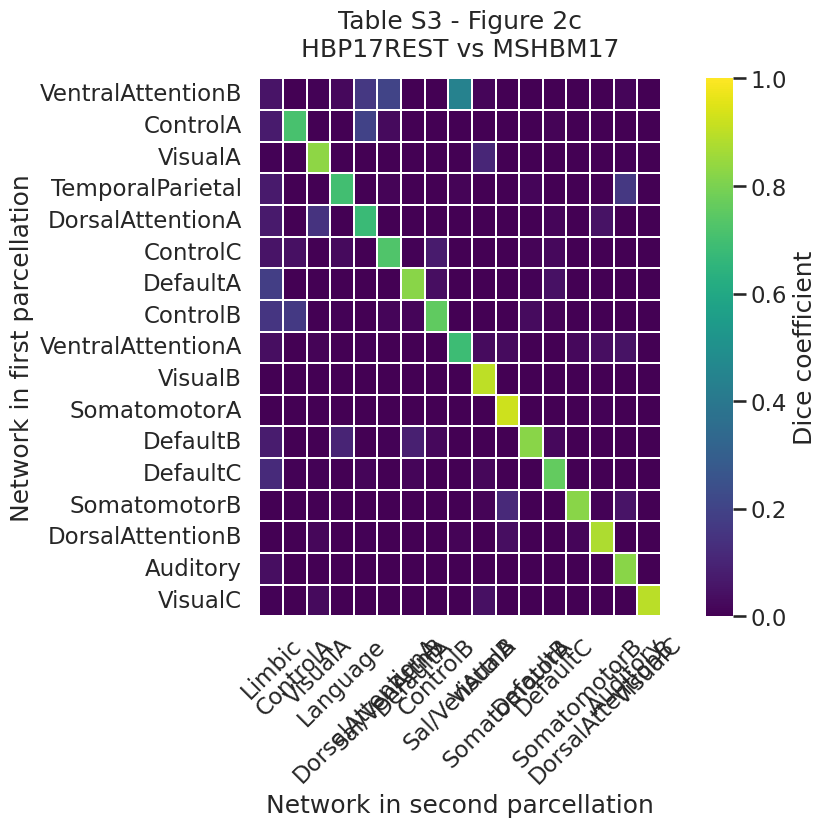

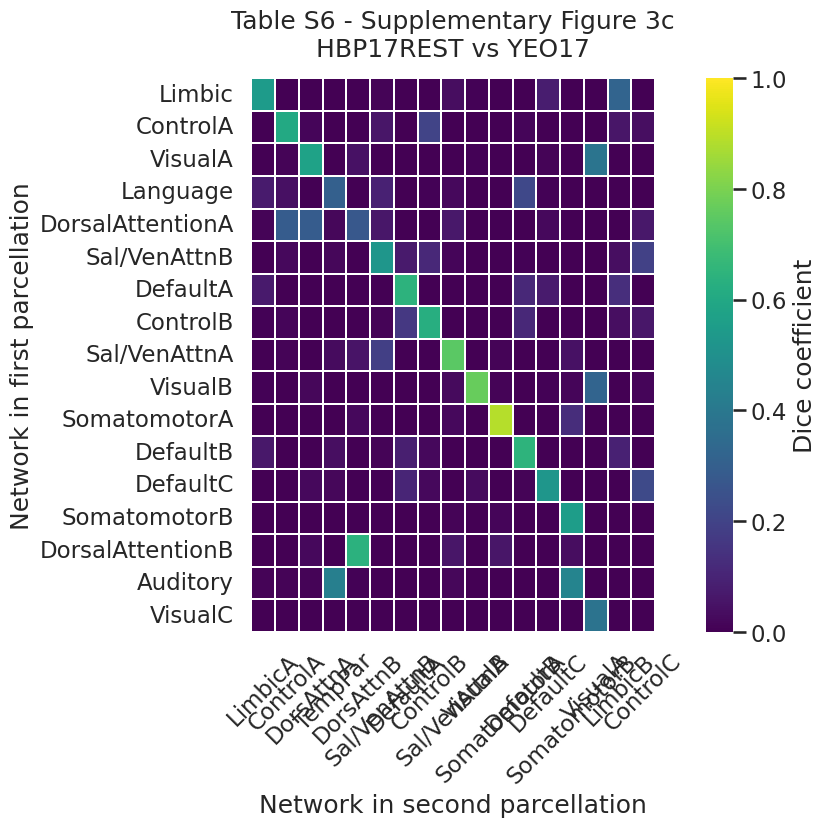

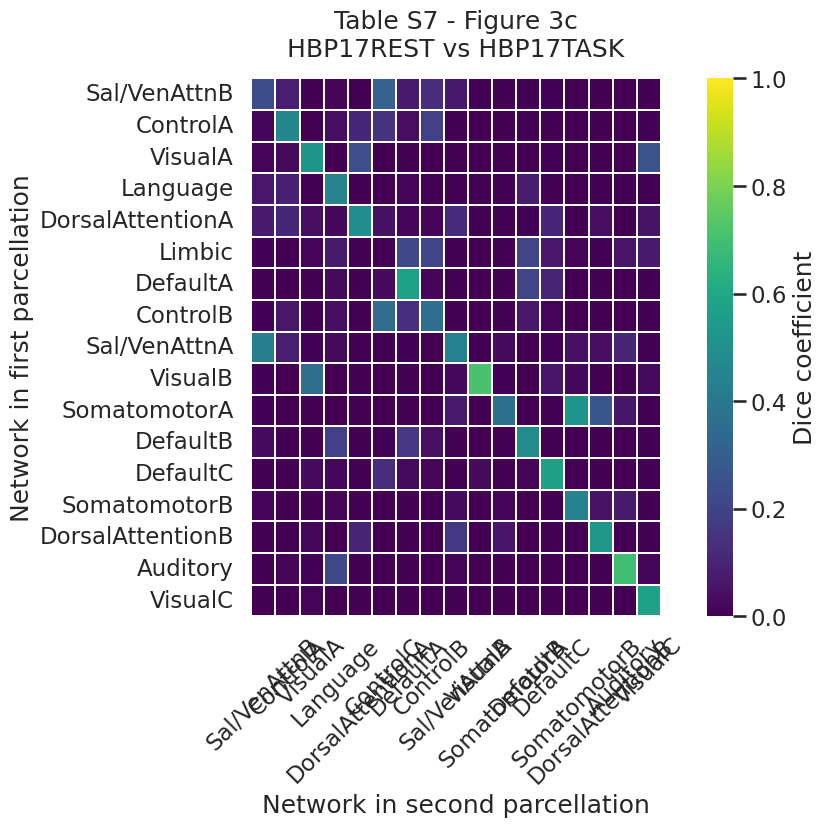

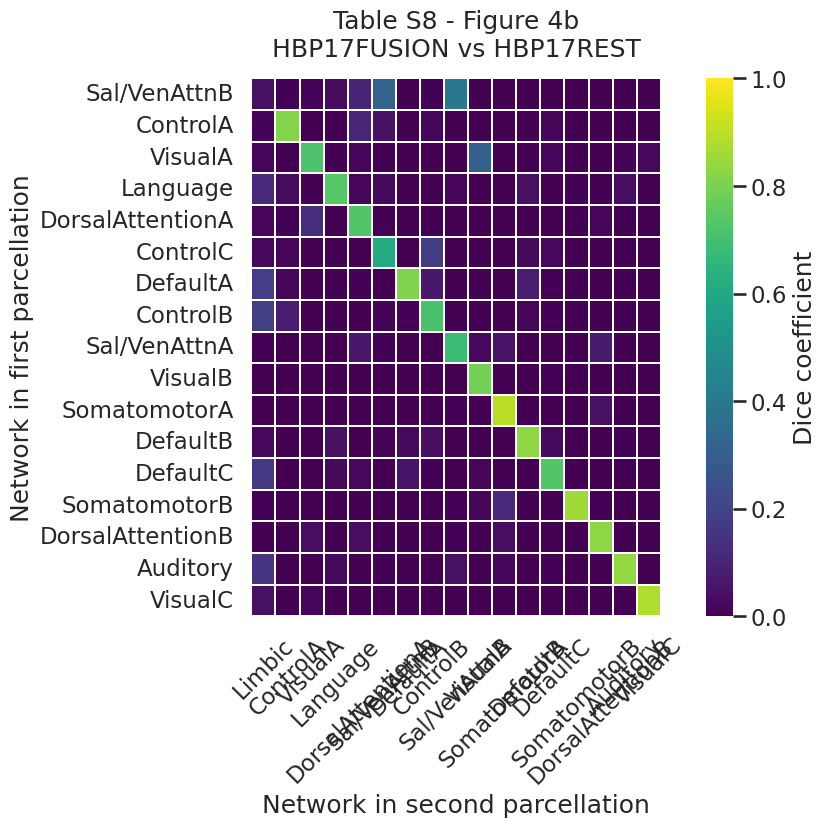

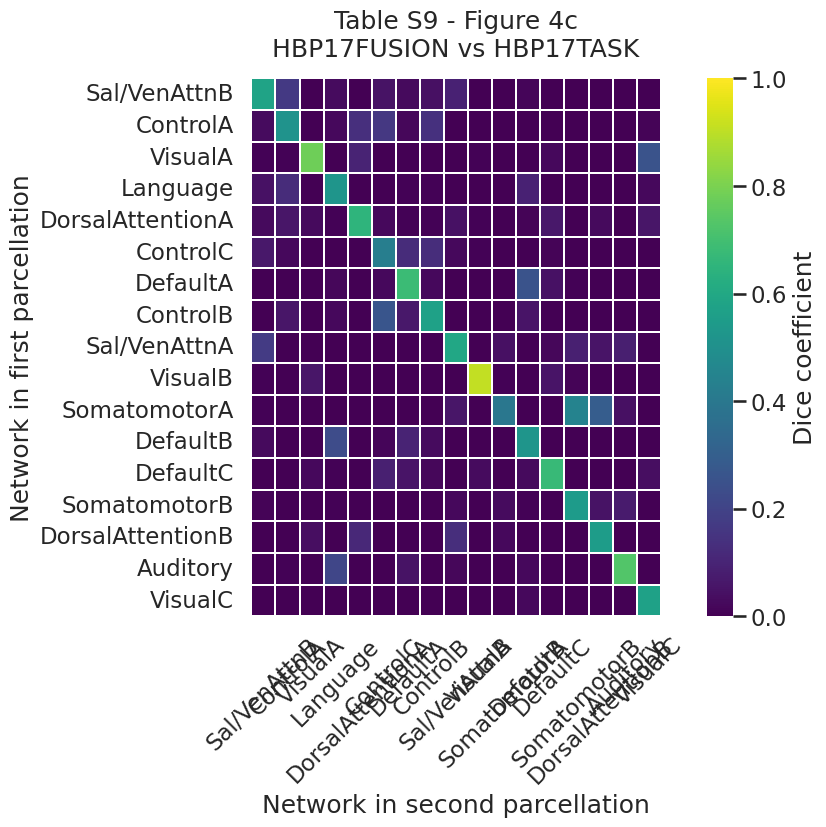

In [7]:
for item in TABLE_INFO:
    matrix = dice_matrices[item["table"]]
    width = max(8, 0.48 * matrix.shape[1])
    height = max(7, 0.48 * matrix.shape[0])
    fig, ax = plt.subplots(figsize=(width, height), constrained_layout=True)
    title = f"{item['table']} - {item['panel']}\n{item['comparison']}"
    plot_dice_matrix(matrix, title, ax=ax)

    if SAVE_FIGURES:
        out_file = OUTPUT_DIR / f"{Path(item['file']).stem}_dice_matrix.png"
        fig.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()